# Analysis of Differentially Expressed Genes

### The purpose of this notebook is to establish relationships between the Differentially Expressed Genes (DEGs) across the contrasts of two experimental models created from an RNA-seq experiment that explores the effects of two distinct treatments in combination across distinct experimental groups distinguished by treatment exposure times. 

# <p style = "color: red;"> last step is to configure a rule and reference input output and param directivesto be referenced in the notebook. in the commented out python cells and then delete this cell</p>

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from upsetplot import UpSet, from_indicators

In [27]:
# source_file = snakemake.input["full_data"] # uncomment for snake make
source_file = "../de_analysis/fullDE_tpm_counts.csv"

In [28]:
df = pd.read_csv(source_file)

/tmp/ipykernel_24281/855788403.py:1: DtypeWarning: Columns (0: gene_symbol) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(source_file)


## I. Global Analysis of DEGs and Experimental Groups

The initial steps of this rely on significance matrices that indicate whether or not a specific gene is a GDE for a given contrast. In order to use them in comparison across the contrasts of the two tests performed in Differential Expression Analysis. (The *Model_dfs are used in later analysis to establish other matrices as well)

In [29]:
# separates the experimental group test and the treatment interaction test attributes into separate dfs
expNames = df.columns[df.columns.str.contains("groupTest")].tolist()
expModel_df =  df[['gene_symbol', 'Geneid'] + expNames].set_index(['gene_symbol','Geneid'])
expModel_df.columns = expModel_df.columns.str.replace("groupTest_","",regex = False)

interactionNames = df.columns[df.columns.str.contains("interactionTest")].tolist()
intModel_df =  df[['gene_symbol', 'Geneid'] + interactionNames].set_index(['gene_symbol','Geneid'])
intModel_df.columns = intModel_df.columns.str.replace('interactionTest_', '', regex = False)

# get padj matrix values
exp_disregMat = expModel_df[expModel_df.columns[expModel_df.columns.str.contains('.padj')].tolist()]
int_disregMat = intModel_df[intModel_df.columns[intModel_df.columns.str.contains('.padj')].tolist()]

# adjust 
exp_disregMat.columns = exp_disregMat.columns.str.replace(".padj", "", regex=False)
int_disregMat.columns = int_disregMat.columns.str.replace(".padj", "", regex=False)


exp_disregMat = (exp_disregMat < 0.05).astype(bool)
int_disregMat = (int_disregMat < 0.05).astype(bool)


Two matrices are constructed below, one for each of the two tests conducted in DESeq2: (1) "Experimental Group Test" where the set of experimental groups are used as predictors (2) "Treatment Interactive Test" where the timed exposures across the two treatments used in the experiment are use as predictors. The data objects (rows in the data frame) represent all the genes found to have been differentially expressed in any of the contrasts found across the contrasts of each test. The datasets' attributes (columns) represent the contrasts identified in their respective test. The each column indicates whether each gene in the dataset is found to be a DGE in that contrast or not. 

"Experimental Group Test" contrasts (relative to the 0hr control group): 

- CO_4hr_APAP_24hr_vs_Control
- CO_24hr_vs_Control
- Control_24hr_vs_Control
- CO_4hr_APAP_4hr_vs_Control
- CO_8hr_APAP_8hr_vs_Control
- CO_4hr_vs_Control
- APAP_4hr_vs_Control

"Treatment Interaction Test" contrasts : 
- co_time_4hr_vs_0hr (clarifies the main effect of the extract)
- apap_time_4hr_vs_0hr (clarifies the main effect of the acetaminophen)
- co_time4hr.apap_time4hr (clarifies the interactive effect: that which is beyond the main effects of the two treatments independently)

In [30]:
print(
f"""
Experimental Group Test Matrix Peek:
{exp_disregMat.head()}

Matrix Size (before filtering):
{exp_disregMat.shape}
""")

exp_disregMat = exp_disregMat[exp_disregMat.sum(axis=1) != 0]

print(
f"""
Matrix Size (after filtering):
{exp_disregMat.shape}
""")



Experimental Group Test Matrix Peek:
                                CO_4hr_APAP_24hr_vs_Control  \
gene_symbol Geneid                                            
ACTB        ENSG00000075624.17                         True   
MT2A        ENSG00000125148.7                          True   
ACTG1       ENSG00000184009.13                         True   
ZFAS1       ENSG00000177410.14                         True   
KRT7        ENSG00000135480.17                         True   

                                CO_24hr_vs_Control  Control_24hr_vs_Control  \
gene_symbol Geneid                                                            
ACTB        ENSG00000075624.17                True                     True   
MT2A        ENSG00000125148.7                 True                     True   
ACTG1       ENSG00000184009.13                True                     True   
ZFAS1       ENSG00000177410.14                True                    False   
KRT7        ENSG00000135480.17                

In [31]:

print(
f"""
Interaction Test Matrix Peek:
{int_disregMat.head()}

Matrix Size (before filtering):
{int_disregMat.shape}
""")

int_disregMat = int_disregMat[int_disregMat.sum(axis=1) != 0]

print(
f"""
Matrix Size (after filtering):
{int_disregMat.shape}
""")


Interaction Test Matrix Peek:
                                co_time_4hr_vs_0hr  apap_time_4hr_vs_0hr  \
gene_symbol Geneid                                                         
ACTB        ENSG00000075624.17                True                 False   
MT2A        ENSG00000125148.7                False                 False   
ACTG1       ENSG00000184009.13                True                 False   
ZFAS1       ENSG00000177410.14               False                  True   
KRT7        ENSG00000135480.17               False                 False   

                                co_time4hr.apap_time4hr  
gene_symbol Geneid                                       
ACTB        ENSG00000075624.17                    False  
MT2A        ENSG00000125148.7                     False  
ACTG1       ENSG00000184009.13                    False  
ZFAS1       ENSG00000177410.14                    False  
KRT7        ENSG00000135480.17                    False  

Matrix Size (before filtering

**(1.a)** The following table and bar graph provide the number of DEGs found for each contrast in the "Experimental Group Test"

Total number of DEGs across experimental group contrasts: 1926 

Number of DEGs per contrast: 
CO_4hr_APAP_24hr_vs_Control    1344
CO_24hr_vs_Control              443
Control_24hr_vs_Control         343
CO_4hr_APAP_4hr_vs_Control      172
CO_8hr_APAP_8hr_vs_Control      256
CO_4hr_vs_Control                30
APAP_4hr_vs_Control             106
dtype: int64


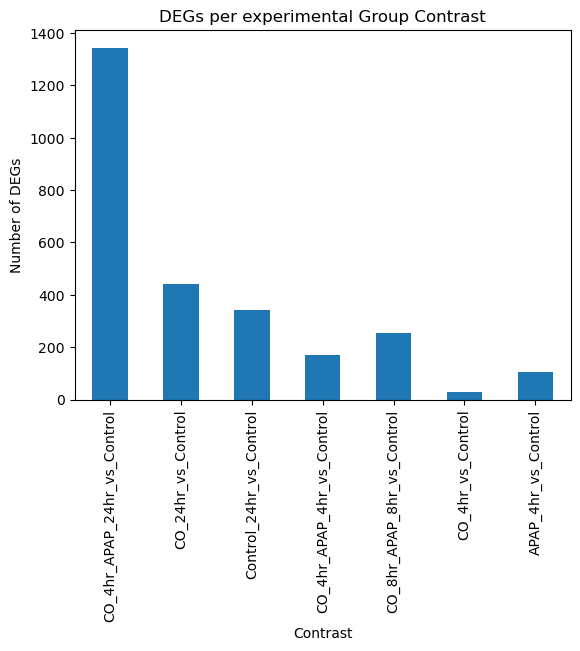

In [32]:
print(f"Total number of DEGs across experimental group contrasts: {exp_disregMat.shape[0]} \n")
col_sums = exp_disregMat.sum(axis = 0)
print(f"Number of DEGs per contrast: \n{col_sums}")
col_sums.plot(kind="bar")
plt.ylabel("Number of DEGs")
plt.xlabel("Contrast")
plt.title("DEGs per experimental Group Contrast")
plt.show()

**(1.b)** The following table and bar graph provide the number of DEGs found for each contrast in the "Treatment Interaction Test"


Total number of DEGs across interaction test contrasts: 161 

Number of DEGs per contrast: 
co_time_4hr_vs_0hr          41
apap_time_4hr_vs_0hr       132
co_time4hr.apap_time4hr     18
dtype: int64


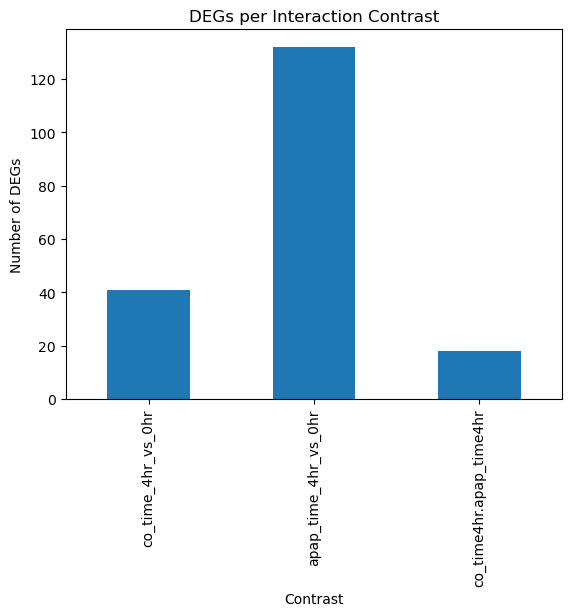

In [33]:
print(f"Total number of DEGs across interaction test contrasts: {int_disregMat.shape[0]} \n")
col_sums = int_disregMat.sum(axis = 0)
print(f"Number of DEGs per contrast: \n{col_sums}")
col_sums.plot(kind="bar")
plt.ylabel("Number of DEGs")
plt.xlabel("Contrast")
plt.title("DEGs per Interaction Contrast")
plt.show()

**(2.a)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

/home/jbennett/miniconda3/envs/CO-timed-expression/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/jbennett/miniconda3/envs/CO-timed-expression/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


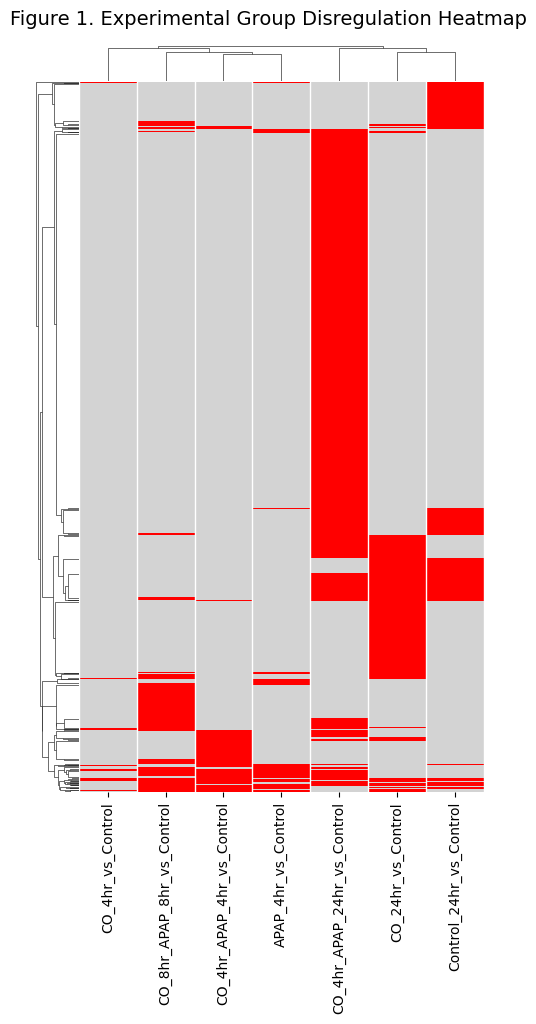

In [34]:
cmap = ListedColormap(["lightgray", "red"])

# Plot heatmap
g = sns.clustermap(exp_disregMat, figsize=(5, 10),
                  metric='jaccard', method= 'average',
                  cmap=cmap, yticklabels = False,
                  # linecolor="white", linewidths = 1,
                  cbar_pos=None,
                  dendrogram_ratio=(0.1, 0.05)
                  # vmin=0, vmax=1
                  )

heatmap_ax = g.ax_heatmap
num_cols = exp_disregMat.shape[1]

for i in range(num_cols + 1):
    heatmap_ax.axvline(i, color='white', linewidth=1)
# Customize colorbar ticks and labels
# cbar = ax.collections[0].colorbar
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(["not significant", "significant"])
plt.suptitle("Figure 1. Experimental Group Disregulation Heatmap", y=1, va='bottom', fontsize=14)
plt.ylabel("")
plt.show()

Figure 1. is a hierarchically clustered heatmap of the full set DEGs that were found in any of the individual contrasts between each treatment group and the zero hour control in the group. The clustering algorithm groups genes by similarity in the binary distribution of significant expression across all of the samples. Because the data is binary, euclidean distance was rejected as a proximity measure. Because most of the genes are not expressed across most treatment group contrasts, Jaccuard was chosen over Hamming as a proximity measure to ensure that genes would not be clustered together as a result of higher frequency of non-significant expression across contrasts. In other words the clustering is based on the similarity in when the genes do cluster together rather than when they don't. This holds for the clustering of contrasts where they are grouped based on which DEGs they do have in common. The 4 hour co-extract with 24 hour acetaminophen exposures yielded the greatest amount of significant gene expression perturbation while the 4 hour exposure to the extract with no acetaminophen showed the least perturbation.

There are two experimental groups that were exposed only to co-extract: for 4 hours and 24 hours respectively. The general disparity in the genes with significant perturbation in these two groups might indicate different states of cellular activity at these different levels of exposure. This interpretation of disparity is fortified by the clustering distances between these contrasts in the horizontal dendrogram at the top of the heatmap. This could suggest that the effects of the extract does not perpetuate specific cellular functions over the length of exposures being studied for co-extract. This will be assessed in downstream analysis.

Similar disparity can be seen between experimental groups that were exposed to both the extracts for the same amount of time: 4 hours and 8 hours, respectively. However there is more similarity between these experimental groups than the groups exposed only to the co-extract, being clustered together at a lower level of the dendrogram and having more overlap in the gene groups that showed significant expression. However, there is more relationship between the 4 hour bi-treatment group and the 4 hour acetaminophen-only treatment group than there is between the 4 and 8 hour bi-treatment groups. Furthermore, given the relative similarity between these three groups compared to the  amount of similarity with the 4 hour extract-only group, might suggest that there is a reductive effect on the disregulation occurring due to acetaminophen when exposed to co-extract. On the other hand, it could mean that the independent contribution to overall perturbation due the extract is simply less than that due to the acetaminophen without having a reductive effect. It will be difficult to parse the implications of these observations in downstream analysis due to the need for opportunity to distinguish the independent effects of both treatments at the 8 hour level. 

These observations do not in any way rule out the interactive effect of the treatments on functional activity that might be occurring in response to the exposure. At this level of analysis it is not possible to clarify genes that are known to participate in the same pathways as being significantly expressed. It is possible that the gene level clustering has identified some true biological signal but is much more likely that it reveals more information about the relationships between samples, that it does about relationships between genes. Downstream analysis will be performed for more robust clustering analysis

**(2.b)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

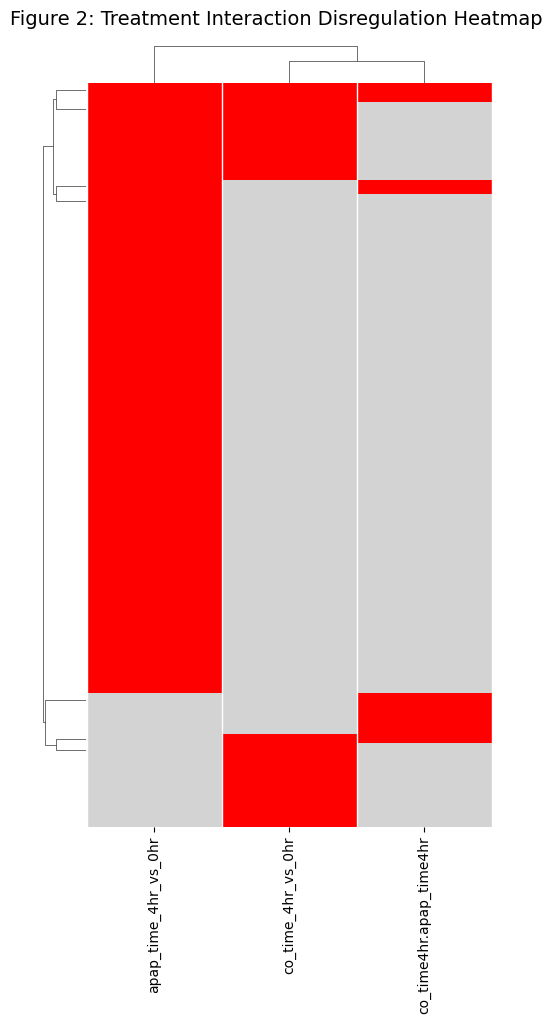

In [35]:
cmap = ListedColormap(["lightgray", "red"])

# Plot heatmap
g = sns.clustermap(int_disregMat, figsize=(5, 10),
                    cmap=cmap, yticklabels = False,
                    # linecolor="white", linewidths = 1,
                    cbar_pos=None,
                    dendrogram_ratio=(0.1, 0.05)
                    # vmin=0, vmax=1
                    )

heatmap_ax = g.ax_heatmap
num_cols = exp_disregMat.shape[1]

for i in range(num_cols + 1):
    heatmap_ax.axvline(i, color='white', linewidth=1)
# Customize colorbar ticks and labels
# cbar = ax.collections[0].colorbar
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(["not significant", "significant"])
plt.suptitle("Figure 2: Treatment Interaction Disregulation Heatmap", y=1, va='bottom', fontsize=14)
plt.ylabel("")
plt.show()

Figure 2. is a hierarchically clustered heatmap of the full set of DEGs that were found in any of the individual contrasts from the interaction test. The test was performed on a subset of samples restricted to exposures intervals of 0-4 hours for both treatments. This test was conducted as a robust means to identify DEGs that are expressed at levels statistically significant beyond was can be explained by the treatments independently. However, the circumstances under which the test was conducted leave doubt in the accuracy of its results. Due to the full rank requirement for the predictive matrix made for generating a test statistic, the number of samples were less than ideal for this test which could lead to type II errors (failing to reject the null). It is possible that there are more genes whose expression in the presence of both treatments was different to a statistically significant level than what occurs as a result of each treatment independently. In addition, the fact that the maximum exposure was limited to 4 hours for each treatment can further confound the results since it is evident when looking at all of the contrasts to the 0 hour control across the treatment groups that maximum perturbation does not occur at 4 hour exposure mark. Relaxing the statistical threshold for rejecting the null is not sufficient because it implicitly assumes that the distribution the test is conducted in would be the same if there were additional samples for higher exposure times. As a consequence the analysis of interactivity will not consider the results of this test. 

**(3)** ...

___

___

## This analyzes patterns in direction of expression across experimental group contrasts

In [ ]:
# get padj matrix values
exp_directionMat = expModel_df[expModel_df.columns[expModel_df.columns.str.contains('.significance')].tolist()]


# adjust 
exp_directionMat.columns = exp_directionMat.columns.str.replace(".significance", "", regex=False)

exp_directionMat[exp_directionMat == "upregulated"] = '1'
exp_directionMat[exp_directionMat == "downregulated"] = '0'
exp_directionMat[exp_directionMat == "not significant"] = '-1'

exp_directionMat = exp_directionMat.astype(int)

print(exp_directionMat.head())


                                CO_4hr_APAP_24hr_vs_Control  \
gene_symbol Geneid                                            
ACTB        ENSG00000075624.17                            0   
MT2A        ENSG00000125148.7                             0   
ACTG1       ENSG00000184009.13                            0   
ZFAS1       ENSG00000177410.14                            1   
KRT7        ENSG00000135480.17                            0   

                                CO_24hr_vs_Control  Control_24hr_vs_Control  \
gene_symbol Geneid                                                            
ACTB        ENSG00000075624.17                   0                        0   
MT2A        ENSG00000125148.7                    0                        0   
ACTG1       ENSG00000184009.13                   0                        0   
ZFAS1       ENSG00000177410.14                   1                       -1   
KRT7        ENSG00000135480.17                   0                        0   

    